# Lead Scoring and Clustering Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

# Pipeline & Preprocessing (StandardScaler removed for pure 0/1 one-hot matrices)
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# The Baseline Engines
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

### Step 0: Environment Setup and Global Configuration

In this section, we import the necessary libraries and establish a universal random seed to ensure that all data splits and model initializations are reproducible.

In [2]:
# --- SEED LOCK ---
def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seeds(42)
print('>>> Universal Random Seed Locked to 42.')

>>> Universal Random Seed Locked to 42.


### Step 1: Data Cleaning and Preprocessing

This function handles the initial loading, cleaning, and standardization of the lead data. It removes irrelevant columns, renames others for consistency, normalizes target labels, and removes incomplete or duplicate records.

In [3]:
def clean_data(file_path):
    """
    Loads, cleans, and standardizes lead data for modeling.

    Args:
        file_path (str): Path to the source CSV file.
    Returns:
        pd.DataFrame: Cleaned dataset with standardized lead statuses.
    """
    # Load dataset and create a copy to avoid SettingWithCopy warnings
    df = pd.read_csv(file_path).copy()

    # Remove columns that do not contribute to predictive power
    df = df.drop(columns=['full_name', 'write_about_your_business_in_short'])

    # Standardize column naming convention for downstream consistency
    df = df.rename(columns={
        'select_the_type_of_activity': 'activity_type',
        'choose_your_preferred_location?': 'location',
        'Lead Status': 'lead_status'
    })

    # Normalize target labels and consolidate prospect types
    df['lead_status'] = df['lead_status'].str.lower().str.strip()
    df['lead_status'] = df['lead_status'].replace({
        'hot prospect': 'hot',
        'warm prospect': 'warm',
        'intrested': 'interested'
    })

    # Performance verification logging: Before cleaning
    print('--- TARGET VERIFICATION ---')
    print(f"Nulls in 'lead_status' before dropping: {np.count_nonzero(df['lead_status'].isnull().to_numpy())}")
    print(f"Duplicates before cleaning: {np.count_nonzero(df.duplicated().to_numpy())}")

    # Remove incomplete records and redundant entries
    df = df.dropna(subset=['lead_status'])
    df = df.drop_duplicates()

    # Performance verification logging: After cleaning
    print(f"Nulls in 'lead_status' after dropping: {np.count_nonzero(df['lead_status'].isnull().to_numpy())}")
    print(f"Duplicates after cleaning: {np.count_nonzero(df.duplicated().to_numpy())}\n")

    return df

### Step 2: Feature Engineering Pipeline

This function constructs a `ColumnTransformer` to automate the preprocessing of categorical features. It includes imputation for missing values and one-hot encoding to convert categorical data into a numerical format suitable for machine learning models.

In [4]:
def build_pipeline():
    """
    Constructs a ColumnTransformer for preprocessing categorical features.

    Returns:
        ColumnTransformer: Preprocessing engine utilizing Imputation and One-Hot Encoding.
    """
    # Identify features requiring categorical encoding
    one_hot_cols = ['activity_type', 'location']

    # Define transformation pipeline: Impute missing entries then encode as binary features
    category_pipeline = Pipeline([
        ('fill_holes', SimpleImputer(strategy='constant', fill_value='missing')),
        ('one_hot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])

    # Construct the transformer to apply encoding while passing through other data
    transformer = ColumnTransformer([
        ('one_hot', category_pipeline, one_hot_cols)
    ], remainder='passthrough', verbose_feature_names_out=False)

    return transformer

### Step 3: Unsupervised Learning - Clustering Setup

In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import OneHotEncoder as OHE

### Unsupervised Learning - K-Means and DBSCAN Analysis

In this section, we apply K-Means and DBSCAN to the cleaned dataset to identify natural clusters. We specifically focus on discovering hidden patterns within the 'others' activity category to find high-priority lead niches. Visualizations are generated to help determine the optimal number of clusters (K) and evaluate the clustering results.

--- TARGET VERIFICATION ---
Nulls in 'lead_status' before dropping: 68
Duplicates before cleaning: 364
Nulls in 'lead_status' after dropping: 0
Duplicates after cleaning: 0

Clustering feature matrix shape: (108, 34)
Features (34 total): ['text_length', 'activity_type_advertising', 'activity_type_architecture', 'activity_type_business_consultancy', 'activity_type_design_services', 'activity_type_e-commerce', 'activity_type_event_management', 'activity_type_fashion_design_consultancy', 'activity_type_food_&_beverage_trading', 'activity_type_forex_trading', 'activity_type_general_trading', 'activity_type_human_resource_consultancy', 'activity_type_interior_design', 'activity_type_it_consultancy', 'activity_type_lifestyle_consultancy', 'activity_type_management_consultancy', 'activity_type_marketing_services', 'activity_type_media_services', 'activity_type_online_education', 'activity_type_others', 'activity_type_production', 'activity_type_project_management_consultancy', 'activity_type_

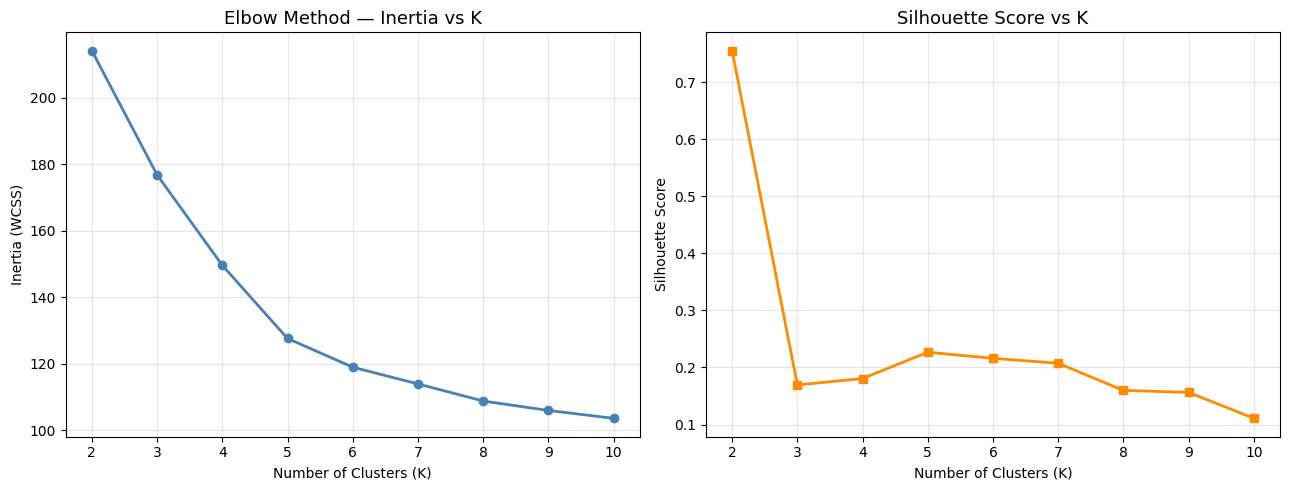


Best K = 2  (Silhouette = 0.7552)

Cluster distribution (K=2):
cluster_id
0    107
1      1
Name: count, dtype: int64

Silhouette Score : 0.7552 
Davies-Bouldin   : 0.1676 

 Lead Status Distribution per Cluster
(0.0 = interested, 1.0 = warm, 2.0 = hot)
lead_status  hot  interested  warm
cluster_id                        
0             19          69    19
1              0           1     0


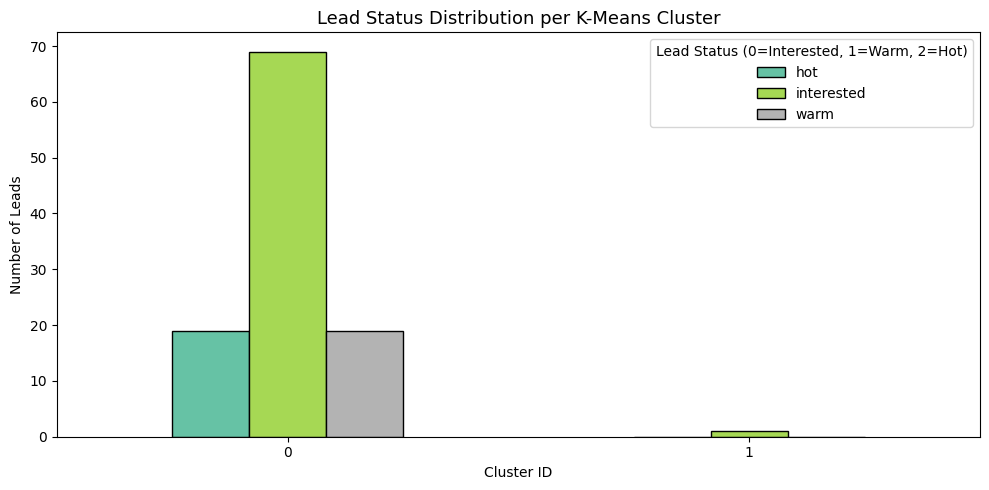

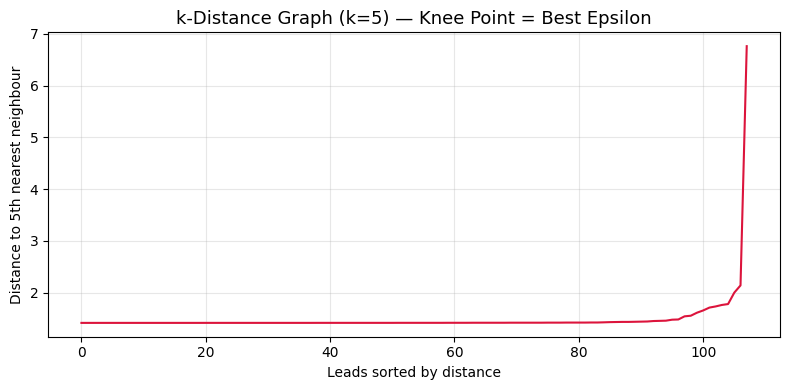


DBSCAN (full dataset, eps=1.5): 1 clusters, 7 noise points

--- Trend Discovery inside 'others' ---
'others' records: 7

K-Means silhouette scores for 'others' sub-clustering:
  K=2  Silhouette=0.3760
  K=3  Silhouette=0.2801
  K=4  Silhouette=0.5360
  K=5  Silhouette=0.4737

Best sub-cluster K = 4  (Silhouette=0.5360)
DBSCAN noise points in 'others': 7

--- Lead Status per 'others' Sub-Cluster ---
(If hot leads concentrate in one sub-cluster, that sub-type is a high-priority niche)
lead_status  hot  interested  warm
sub_cluster                       
0              0           1     1
1              0           1     0
2              1           0     1
3              1           1     0

X_supervised shape : (108, 36)
y_supervised counts:
lead_status
interested    70
warm          19
hot           19
Name: count, dtype: int64

X_supervised and y_supervised are ready for Person 3 (Logistic Regression) and Person 4 (Random Forest).


In [6]:
# Load cleaned data
final_data = clean_data('company.csv')
raw_data = pd.read_csv('company.csv')
raw_data['text_length'] = raw_data['write_about_your_business_in_short'].fillna('').str.len()
final_data['text_length'] = raw_data.loc[final_data.index, 'text_length']
final_data = pd.get_dummies(final_data, columns=['activity_type', 'location'], prefix_sep='_', dummy_na=False)

# Feature Matrix
X_cluster = final_data.drop(columns=['lead_status']).copy()

scaler = StandardScaler()
X_cluster['text_length'] = scaler.fit_transform(X_cluster[['text_length']])

print(f"Clustering feature matrix shape: {X_cluster.shape}")
print(f"Features ({len(X_cluster.columns)} total): {list(X_cluster.columns)}\n")


#Finding best K value
inertia_values    = []
silhouette_values = []
K_range           = range(2, 11)

for k in K_range:
    km     = KMeans(n_clusters=k, init='k-means++', n_init=20, max_iter=500, random_state=42)
    labels = km.fit_predict(X_cluster)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_cluster, labels))
    print(f"K={k:2d}  |  Inertia={km.inertia_:8.2f}  |  Silhouette={silhouette_values[-1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(list(K_range), inertia_values, marker='o', color='steelblue', linewidth=2)
ax1.set_title('Elbow Method — Inertia vs K', fontsize=13)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_range), silhouette_values, marker='s', color='darkorange', linewidth=2)
ax2.set_title('Silhouette Score vs K', fontsize=13)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_k_selection.png', dpi=150)
plt.show()

BEST_K = list(K_range)[silhouette_values.index(max(silhouette_values))]
print(f"\nBest K = {BEST_K}  (Silhouette = {max(silhouette_values):.4f})")


# K-Means model
final_km = KMeans(n_clusters=BEST_K, init='k-means++', n_init=20, max_iter=500, random_state=42)
final_data['cluster_id'] = final_km.fit_predict(X_cluster)

print(f"\nCluster distribution (K={BEST_K}):")
print(final_data['cluster_id'].value_counts().sort_index())

sil = silhouette_score(X_cluster, final_data['cluster_id'])
dbi = davies_bouldin_score(X_cluster, final_data['cluster_id'])
print(f"\nSilhouette Score : {sil:.4f} ")
print(f"Davies-Bouldin   : {dbi:.4f} ")



print("\n Lead Status Distribution per Cluster")
print("(0.0 = interested, 1.0 = warm, 2.0 = hot)")
enrichment = final_data.groupby('cluster_id')['lead_status'].value_counts().unstack(fill_value=0)
print(enrichment)

enrichment.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Lead Status Distribution per K-Means Cluster', fontsize=13)
plt.xlabel('Cluster ID')
plt.ylabel('Number of Leads')
plt.xticks(rotation=0)
plt.legend(title='Lead Status (0=Interested, 1=Warm, 2=Hot)')
plt.tight_layout()
plt.savefig('kmeans_cluster_profiles.png', dpi=150)
plt.show()


#DBSCAN
MIN_PTS = 5
nbrs        = NearestNeighbors(n_neighbors=MIN_PTS).fit(X_cluster)
distances, _ = nbrs.kneighbors(X_cluster)
k_distances  = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances, color='crimson', linewidth=1.5)
plt.title(f'k-Distance Graph (k={MIN_PTS}) — Knee Point = Best Epsilon', fontsize=13)
plt.xlabel('Leads sorted by distance')
plt.ylabel(f'Distance to {MIN_PTS}th nearest neighbour')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_epsilon.png', dpi=150)
plt.show()

EPSILON = 1.5

db_full  = DBSCAN(eps=EPSILON, min_samples=MIN_PTS)
db_labels = db_full.fit_predict(X_cluster)

n_clusters_found = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise          = list(db_labels).count(-1)
print(f"\nDBSCAN (full dataset, eps={EPSILON}): {n_clusters_found} clusters, {n_noise} noise points")


# Finding Trends
print("\n--- Trend Discovery inside 'others' ---")

others_mask     = final_data['activity_type_others'] == 1.0
others_df       = final_data[others_mask].copy()
print(f"'others' records: {len(others_df)}")

location_cols   = [c for c in others_df.columns if c.startswith('location_')]
others_features = others_df[location_cols + ['text_length']].copy()
others_features['text_length'] = scaler.fit_transform(others_features[['text_length']])

print("\nK-Means silhouette scores for 'others' sub-clustering:")
best_sil, best_k_others, best_labels_others = -1, 2, None

for k in range(2, 6):
    if len(others_features) <= k:
        break
    km_o  = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    lbl   = km_o.fit_predict(others_features)
    score = silhouette_score(others_features, lbl)
    print(f"  K={k}  Silhouette={score:.4f}")
    if score > best_sil:
        best_sil, best_k_others, best_labels_others = score, k, lbl

others_df = others_df.copy()
others_df['sub_cluster'] = best_labels_others
print(f"\nBest sub-cluster K = {best_k_others}  (Silhouette={best_sil:.4f})")

db_others    = DBSCAN(eps=0.8, min_samples=3)
db_o_labels  = db_others.fit_predict(others_features)
noise_others = (db_o_labels == -1).sum()
print(f"DBSCAN noise points in 'others': {noise_others}")

print("\n--- Lead Status per 'others' Sub-Cluster ---")
print("(If hot leads concentrate in one sub-cluster, that sub-type is a high-priority niche)")
print(others_df.groupby('sub_cluster')['lead_status'].value_counts().unstack(fill_value=0))


cluster_ohe     = OHE(sparse_output=False, handle_unknown='ignore')
cluster_encoded = cluster_ohe.fit_transform(final_data[['cluster_id']])
cluster_cols    = [f'cluster_{i}' for i in range(cluster_encoded.shape[1])]

X_supervised = final_data.drop(columns=['lead_status', 'cluster_id']).copy()
for col, arr in zip(cluster_cols, cluster_encoded.T):
    X_supervised[col] = arr

y_supervised = final_data['lead_status']

print(f"\nX_supervised shape : {X_supervised.shape}")
print(f"y_supervised counts:\n{y_supervised.value_counts()}")
print("\nX_supervised and y_supervised are ready for Person 3 (Logistic Regression) and Person 4 (Random Forest).")


### Step 4: Supervised Learning - Baseline Model Evaluation

This function evaluates several common machine learning classifiers using cross-validation to identify the best-performing baseline model based on accuracy. This step helps in understanding which model type is most suitable for the dataset before fine-tuning.

In [7]:
def evaluate_baselines(X_train, y_train, preprocessor):
    """
    Performs cross-validation across multiple classifiers to identify the best baseline.

    Args:
        X_train: Training features
        y_train: Training labels
        preprocessor: The ColumnTransformer instance
    Returns:
        estimator: The model class that achieved the highest mean accuracy.
    """
    print('\n[2/4] Running Multi-Model Cross-Validation...')

    # Initialize candidate classifiers for baseline evaluation
    models = {
        'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
        'Support Vector Machine': SVC(random_state=42),
        'K-Nearest Neighbors': KNeighborsClassifier(),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42)
    }

    best_model = None
    best_score = 0

    for model_name, model in models.items():
        # Construct model-specific pipeline (Note: Scaler omitted to preserve sparse encoding)
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])

        # Perform 5-fold cross-validation
        scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
        mean_score = np.mean(scores)

        print(f' -> {model_name} Mean CV Score: {mean_score:.4f}')

        # Track and update the top performing model
        if mean_score > best_score:
            best_score = mean_score
            best_model = model

    print(f'\n>>> WINNING BASELINE: {best_model.__class__.__name__} with a score of {best_score:.4f}')
    return best_model

### Step 5: Supervised Learning - Dashboard Visualization

This function generates a detailed dashboard for all baseline models, providing visual insights into their performance. It includes Confusion Matrices, Classification Reports (Precision, Recall, F1-Score), and ROC-AUC curves for a comprehensive evaluation.

In [8]:
def plot_dashboard(X_train, y_train, X_test, y_test, preprocessor):
    """
    Generates a comprehensive evaluation dashboard featuring Confusion Matrices,
    Classification Reports, and ROC Curves for all baseline models.
    """
    print('\n[UI] Generating the Ultimate 3x5 Master Dashboard...')

    # Note: probability=True is required for SVM ROC-AUC calculation
    models = {
        'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
        'SVM': SVC(probability=True, random_state=42),
        'KNN': KNeighborsClassifier(),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42)
    }

    cmaps = ['Blues', 'Purples', 'Greens', 'Oranges', 'Reds']
    classes = ['Interested', 'Warm', 'Hot']
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

    sns.set_theme(style='white', font_scale=1.1)

    # Setup grid for multicomponent evaluation
    fig, axes = plt.subplots(3, 5, figsize=(24, 15))
    fig.suptitle('Baseline Performance Analysis: Clean Architecture Evaluation', fontsize=22, fontweight='bold', y=1.02)

    for col_idx, ((name, model), cmap) in enumerate(zip(models.items(), cmaps)):
        ax_cm = axes[0, col_idx]
        ax_rep = axes[1, col_idx]
        ax_roc = axes[2, col_idx]

        # Standardized inference flow
        pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_proba = pipe.predict_proba(X_test)

        style = dict(cmap=cmap, cbar=False, linewidths=1.5, linecolor='white', annot_kws={'size': 13, 'weight': 'bold'})

        # Row 1: Confusion Matrix Visualization
        cm = confusion_matrix(y_test, y_pred)
        cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
        annot_labels = np.array([[f"{v}\n({cm_pct[i, j]:.0f}%)" for j, v in enumerate(row)] for i, row in enumerate(cm)])

        sns.heatmap(cm, annot=annot_labels, fmt='', ax=ax_cm, xticklabels=['Int', 'Warm', 'Hot'], yticklabels=['Int', 'Warm', 'Hot'], **style)
        ax_cm.set_title(name, fontsize=15, fontweight='bold', pad=10)
        ax_cm.set_xlabel('Predicted', fontsize=11, fontweight='bold')
        if col_idx == 0: ax_cm.set_ylabel('Actual Truth (CM)', fontsize=12, fontweight='bold')

        # Row 2: Precision/Recall/F1-Score and Accuracy Breakdown
        report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        df_report = pd.DataFrame(report_dict).T.drop(columns=['support'])
        df_report.index = ['Interested', 'Warm', 'Hot', 'Accuracy', 'Macro Avg', 'Weighted Avg']

        sns.heatmap(df_report, annot=True, fmt='.2f', ax=ax_rep, **style)
        ax_rep.tick_params(axis='x', rotation=30)
        if col_idx == 0: ax_rep.set_ylabel('Metrics (Report)', fontsize=12, fontweight='bold')
        else: ax_rep.set_yticks([])

        # Row 3: Receiver Operating Characteristic (ROC) Curves
        for i in range(3):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            roc_auc = auc(fpr, tpr)
            ax_roc.plot(fpr, tpr, lw=2.5, label=f'{classes[i]} (AUC={roc_auc:.2f})')

        ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
        ax_roc.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
        ax_roc.legend(loc='lower right', fontsize=10)
        if col_idx == 0: ax_roc.set_ylabel('True Positive Rate (ROC)', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

### Step 6: Supervised Learning - Hyperparameter Tuning and Final Deployment

This function performs hyperparameter tuning using GridSearchCV on the best baseline model identified earlier. It then evaluates the optimized model on unseen test data, presenting its final performance through a dedicated UI that includes a Confusion Matrix, Classification Report, and ROC-AUC curves.

In [9]:
def tune_and_deploy_model(X_train, y_train, X_test, y_test, preprocessor, best_model):
    """
    Performs Hyperparameter Tuning via Grid Search and evaluates the final optimized model.
    """
    print('\n[3/4] Booting GridSearchCV for Hyperparameter Tuning...')

    # Initialize the unified pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', best_model)
    ])

    model_name = best_model.__class__.__name__

    # Define algorithm-specific hyperparameter search spaces
    if model_name == 'SVC':
        param_grid = {
            'classifier__C': [0.1, 1, 10, 100],
            'classifier__kernel': ['linear', 'rbf'],
            'classifier__gamma': ['scale', 'auto'],
            'classifier__probability': [True]
        }
    elif model_name == 'LogisticRegression':
        param_grid = {
            'classifier__C': [0.01, 0.1, 1.0, 10.0],
            'classifier__solver': ['lbfgs', 'liblinear']
        }
    elif model_name == 'RandomForestClassifier':
        param_grid = {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [None, 10, 20]
        }
    elif model_name == 'DecisionTreeClassifier':
        param_grid = {
            'classifier__max_depth': [None, 10, 20],
            'classifier__min_samples_split': [2, 5, 10]
        }
    elif model_name == 'KNeighborsClassifier':
        param_grid = {
            'classifier__n_neighbors': [3, 5, 7],
            'classifier__weights': ['uniform', 'distance']
        }
    else:
        param_grid = {}

    # Execute grid search if a parameter space is defined
    if param_grid:
        grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
        grid.fit(X_train, y_train)
        print(f'\n>>> OPTIMAL HYPERPARAMETERS FOUND FOR {model_name}:')
        print(grid.best_params_)
        best_clf = grid.best_estimator_
    else:
        pipeline.fit(X_train, y_train)
        best_clf = pipeline

    print('\n[4/4] Testing Final Tuned Engine on Unseen Data...\n')
    y_pred = best_clf.predict(X_test)
    y_proba = best_clf.predict_proba(X_test)

    # Final performance visualization reporting
    print(f'>>> Building Final Engine UI for {model_name}...')

    color_router = {'LogisticRegression': 'Blues', 'SVC': 'Purples', 'KNeighborsClassifier': 'Greens', 'DecisionTreeClassifier': 'Oranges', 'RandomForestClassifier': 'Reds'}
    theme_color = color_router.get(model_name, 'Blues')

    sns.set_theme(style='white', font_scale=1.1)
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle(f'Final Deployed Engine: {model_name} (Tuned)', fontsize=18, fontweight='bold', y=1.05)

    style = dict(cmap=theme_color, cbar=False, linewidths=1.5, linecolor='white', annot_kws={'size': 15, 'weight': 'bold'})

    # Panel 1: Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot_labels = np.array([[f"{v}\n({cm_pct[i, j]:.0f}%)" for j, v in enumerate(row)] for i, row in enumerate(cm)])

    sns.heatmap(cm, annot=annot_labels, fmt='', ax=axes[0], xticklabels=['Int', 'Warm', 'Hot'], yticklabels=['Int', 'Warm', 'Hot'], **style)
    axes[0].set(title='Confusion Matrix', ylabel='Actual Truth', xlabel='AI Prediction')

    # Panel 2: Classification Metrics Heatmap
    report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    df_report = pd.DataFrame(report_dict).T.drop(columns=['support'])
    df_report.index = ['Interested', 'Warm', 'Hot', 'Accuracy', 'Macro Avg', 'Weighted Avg']

    sns.heatmap(df_report, annot=True, fmt='.2f', ax=axes[1], **style)
    axes[1].set(title='Precision, Recall & F1-Score')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].set_yticklabels(df_report.index, rotation=0, fontweight='bold')

    # Panel 3: ROC-AUC Multiclass Curve
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
    classes = ['Interested', 'Warm', 'Hot']

    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        axes[2].plot(fpr, tpr, lw=2.5, label=f'{classes[i]} (AUC={roc_auc:.2f})')

    axes[2].plot([0, 1], [0, 1], 'k--', lw=1.5)
    axes[2].set(title='ROC-AUC Curves', xlabel='False Positive Rate', ylabel='True Positive Rate')
    axes[2].legend(loc='lower right', fontsize=11)

    plt.tight_layout()
    plt.show()

### Step 7: Main Execution Flow

This `main` function orchestrates the entire machine learning workflow. It calls the data cleaning, pipeline construction, baseline evaluation, dashboard generation, and final model tuning functions in a sequential manner to process the data and build predictive models.

[1/4] Cleaning Data...
--- TARGET VERIFICATION ---
Nulls in 'lead_status' before dropping: 68
Duplicates before cleaning: 364
Nulls in 'lead_status' after dropping: 0
Duplicates after cleaning: 0

--- PIPELINE Verification ---
Total features generated: 33
Missingness features generated by Imputer: ['location_missing']
----------------------

[2/4] Running Multi-Model Cross-Validation...
 -> Logistic Regression Mean CV Score: 0.6052
 -> Support Vector Machine Mean CV Score: 0.6399
 -> K-Nearest Neighbors Mean CV Score: 0.5843
 -> Decision Tree Mean CV Score: 0.4438
 -> Random Forest Mean CV Score: 0.4667

>>> WINNING BASELINE: SVC with a score of 0.6399

[UI] Generating the Ultimate 3x5 Master Dashboard...


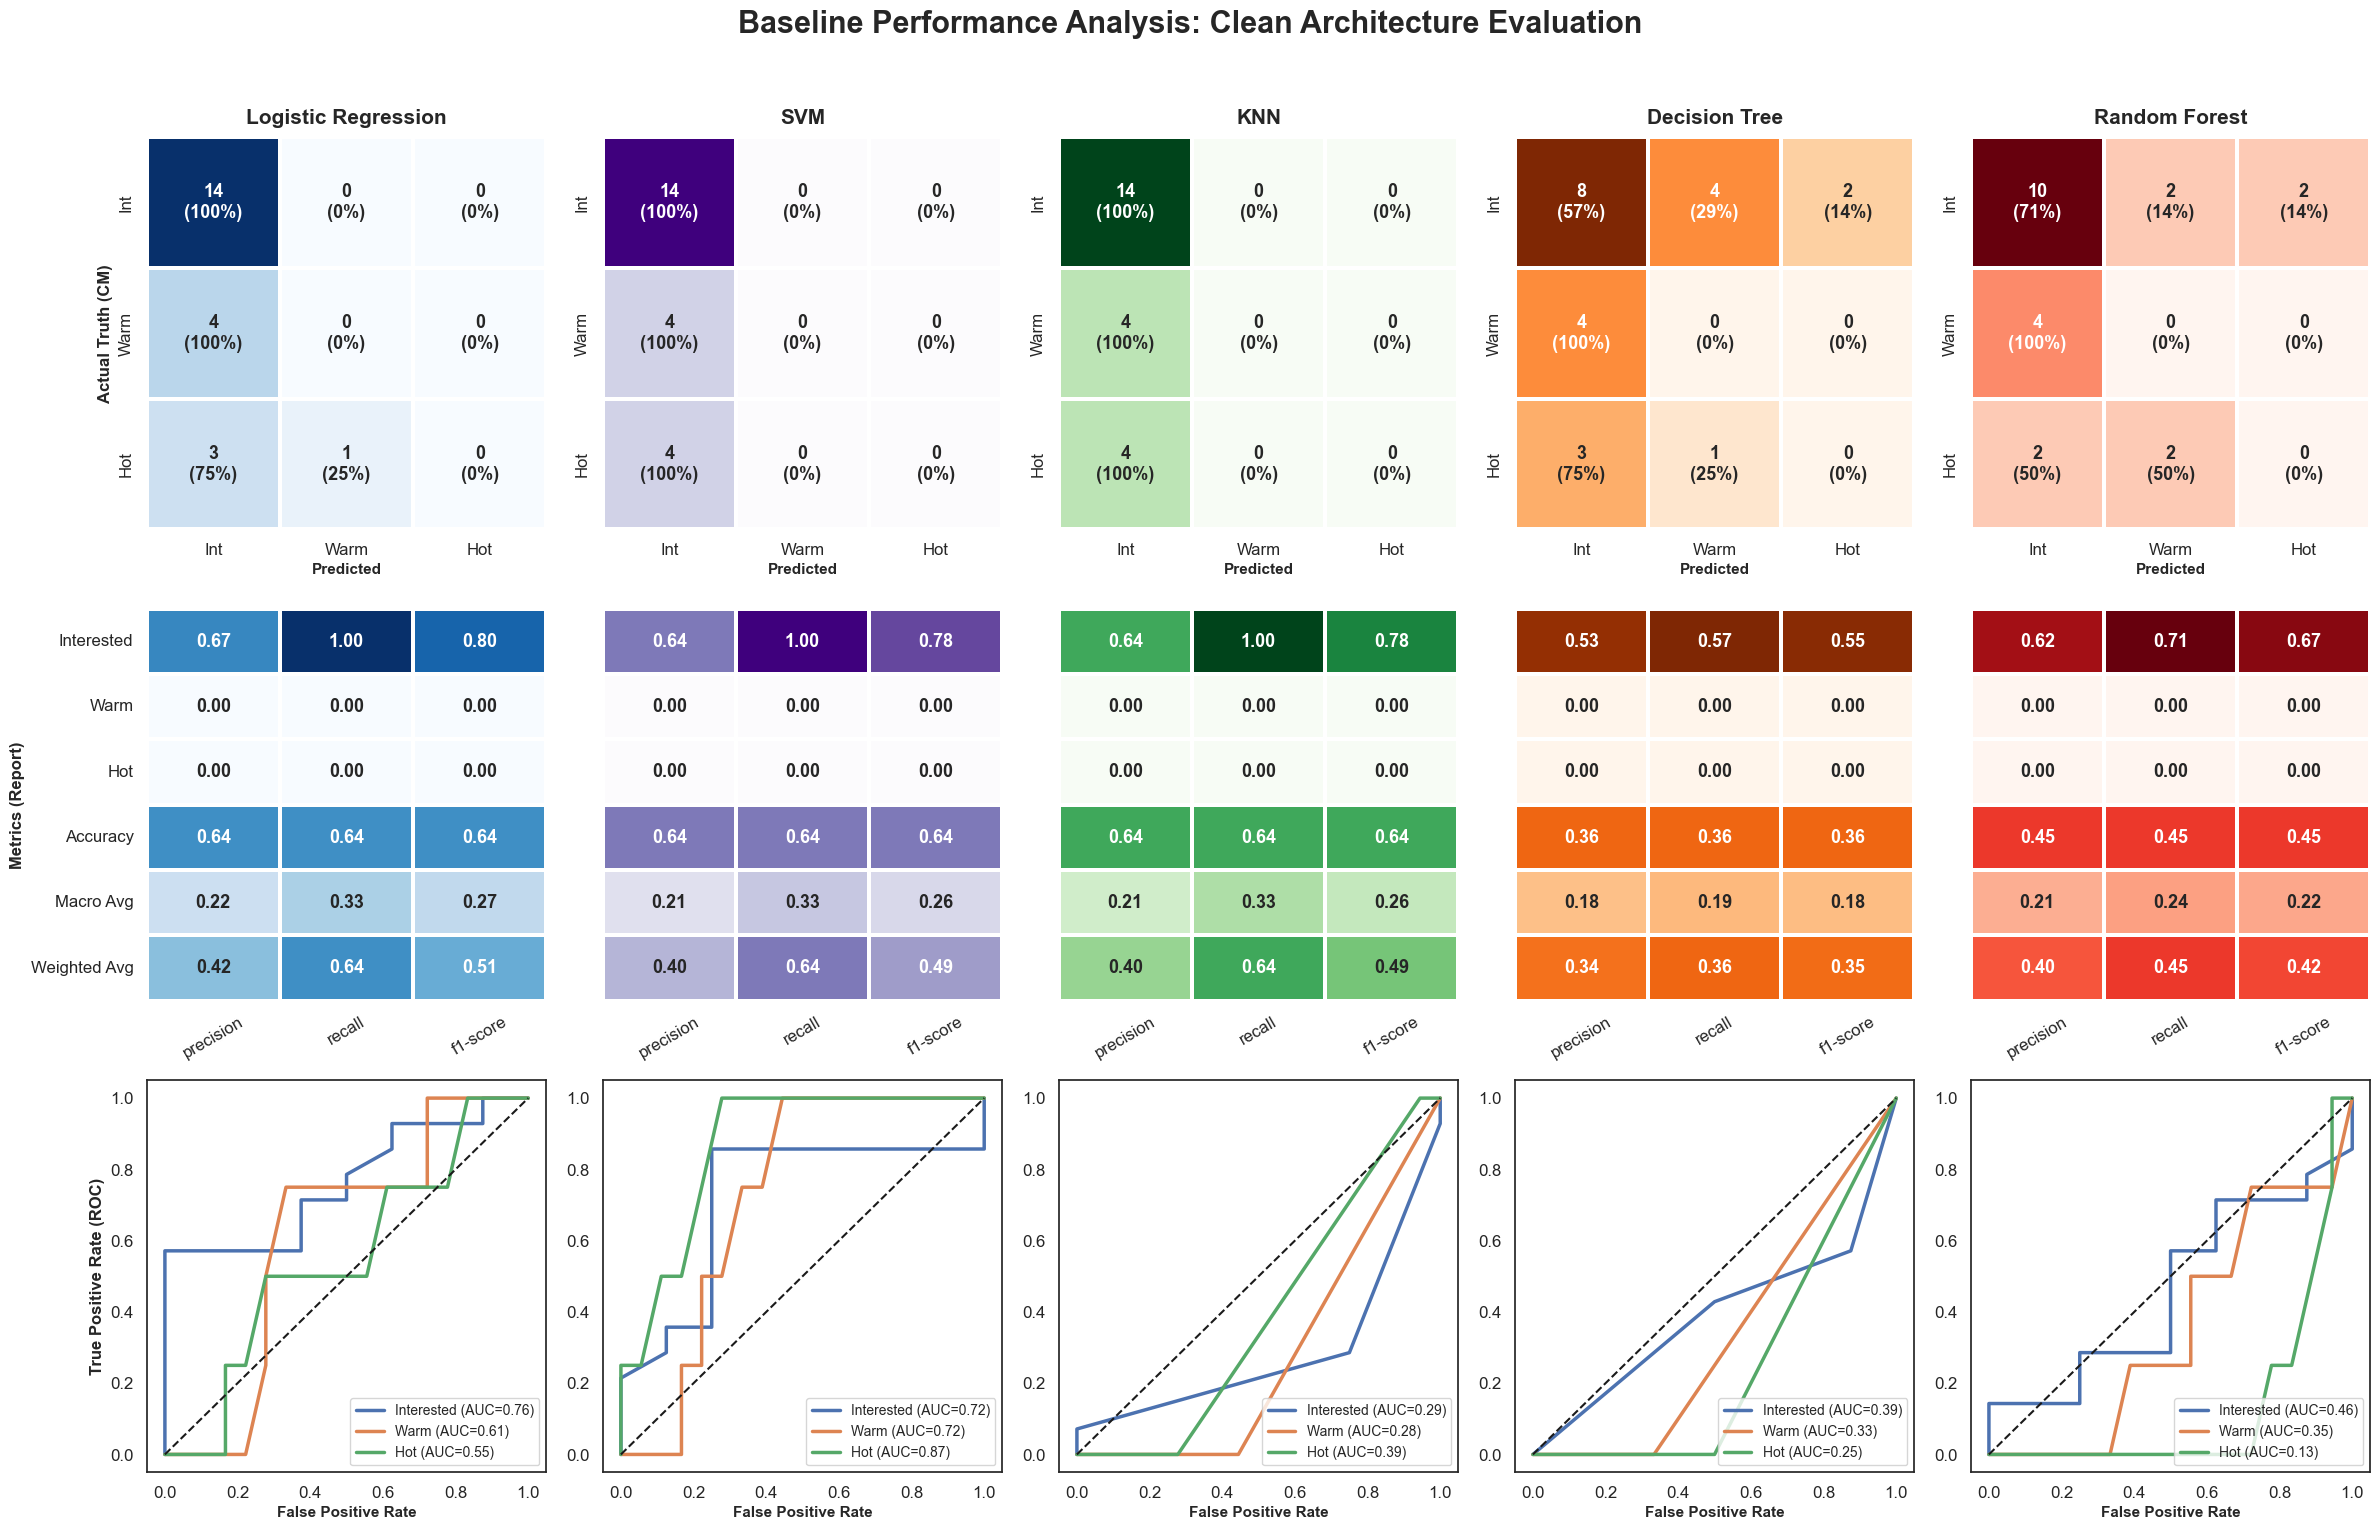


[3/4] Booting GridSearchCV for Hyperparameter Tuning...

>>> OPTIMAL HYPERPARAMETERS FOUND FOR SVC:
{'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear', 'classifier__probability': True}

[4/4] Testing Final Tuned Engine on Unseen Data...

>>> Building Final Engine UI for SVC...


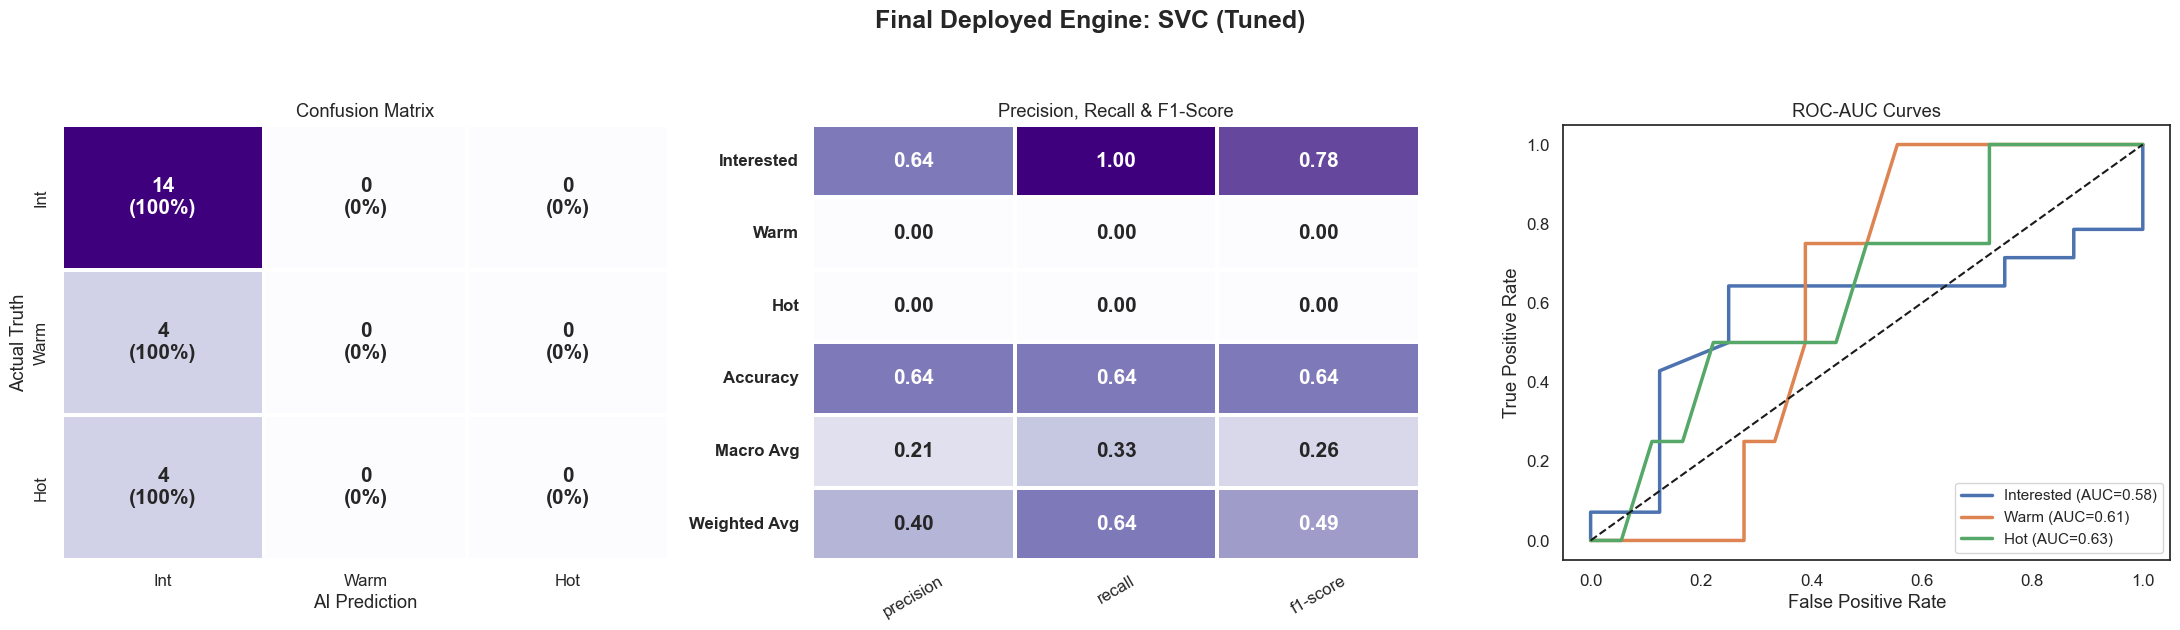

In [10]:
def main():
    """
    Main execution entry point: coordinates the data cleaning, pipeline verification,
    baseline model comparison, dashboard generation, and final model optimization.
    """
    print('[1/4] Cleaning Data...')

    # 1. Source and clean the raw lead dataset
    final_df = clean_data('company.csv')

    # 2. Encode target labels before splitting to ensure consistent mapping
    target_encoder = OrdinalEncoder(categories=[['interested', 'warm', 'hot']])
    final_df['lead_status'] = target_encoder.fit_transform(final_df[['lead_status']])

    # 3. Partition features (X) and target (y)
    X = final_df.drop(columns=['lead_status'])
    y = final_df['lead_status']

    # 4. Perform stratified train-test split to preserve class distribution
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 5. Initialize the transformation pipeline
    preprocessor = build_pipeline()

    # --- Pipeline Structural Verification ---
    print('--- PIPELINE Verification ---')
    X_train_transformed = preprocessor.fit_transform(X_train)

    # Extract and log generated feature names to verify imputation
    generated_columns = preprocessor.get_feature_names_out()
    missing_cols = [col for col in generated_columns if 'missing' in col]

    print(f'Total features generated: {len(generated_columns)}')
    print(f'Missingness features generated by Imputer: {missing_cols}')
    print('----------------------')

    # 6. Evaluate baseline performance and visualize results
    best_model = evaluate_baselines(X_train, y_train, preprocessor)
    plot_dashboard(X_train, y_train, X_test, y_test, preprocessor)

    # 7. Execute hyperparameter tuning and final deployment evaluation
    tune_and_deploy_model(X_train, y_train, X_test, y_test, preprocessor, best_model)

if __name__ == '__main__':
    main()